# Nifty-Lens — Model Training & Evaluation

Training a volatility-regime classifier on the `ml_features` table.

**Problem:** Given technical indicators for (ticker, date), predict the next-5-day
average realized volatility bucket: `low`, `medium`, or `high` (per-ticker tertile split).

**Why 5-day, not next-day?** Initial experiments targeting next-day vol achieved only
39% accuracy (~6pp above random). Single-day vol is dominated by idiosyncratic noise.
Reframing to 5-day average aligns with the well-documented *volatility clustering*
phenomenon — vol is much more predictable over 3-10 day horizons than single days.
This one decision moved accuracy from 39% → 68%.

**Models compared:**
- Logistic Regression (linear baseline)
- XGBoost (final model)

**Key design decisions:**
- Time-based train/test split (no random shuffling — prevents leakage)
- Walk-forward CV using sklearn's `TimeSeriesSplit`
- Per-ticker tertile target (so model learns *relative* vol patterns)
- No hyperparameter tuning beyond a focused sanity check (verified default is within
  0.5pp of best across 7 configurations)

In [10]:
import os
import pickle
from pathlib import Path
from dotenv import load_dotenv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sklearn.metrics import classification_report, confusion_matrix

load_dotenv()
engine = create_engine(
    f"postgresql://{os.getenv('NEON_USER')}:{os.getenv('NEON_PASSWORD')}"
    f"@{os.getenv('NEON_HOST')}:{os.getenv('NEON_PORT')}"
    f"/{os.getenv('NEON_DATABASE')}?sslmode=require"
)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

## 1. Load model and predictions

In [11]:
# Load trained XGBoost model
with open("../models/xgboost_volatility.pkl", "rb") as f:
    model = pickle.load(f)

# Load predictions from Postgres
preds = pd.read_sql("SELECT * FROM ml_predictions ORDER BY date, ticker", engine)
for col in ["prob_low", "prob_medium", "prob_high", "confidence"]:
    preds[col] = preds[col].astype(float)
preds["date"] = pd.to_datetime(preds["date"])

print(f"Test set predictions: {len(preds):,} rows")
print(f"Date range: {preds['date'].min().date()} → {preds['date'].max().date()}")
print(f"Unique tickers: {preds['ticker'].nunique()}")
preds.head()

Test set predictions: 12,092 rows
Date range: 2025-04-21 → 2026-04-15
Unique tickers: 50


,ticker,date,actual_regime,predicted_regime,prob_low,prob_medium,prob_high,confidence,correct
0,ADANIENT.NS,2025-04-21,0,2,0.0360,0.2989,0.6651,0.6651,False
1,ADANIPORTS.NS,2025-04-21,2,2,0.0189,0.2010,0.7800,0.7800,True
2,APOLLOHOSP.NS,2025-04-21,1,1,0.2613,0.5869,0.1517,0.5869,True
3,ASIANPAINT.NS,2025-04-21,1,1,0.3972,0.5343,0.0686,0.5343,True
4,AXISBANK.NS,2025-04-21,2,2,0.0061,0.0679,0.9260,0.9260,True


## 2. Overall accuracy & per-class recall

In [12]:
overall_acc = preds["correct"].mean()
print(f"Overall test accuracy: {overall_acc:.4f}")
print()

print(classification_report(
    preds["actual_regime"],
    preds["predicted_regime"],
    target_names=["low", "medium", "high"],
    digits=4,
))

Overall test accuracy: 0.6780

              precision    recall  f1-score   support

         low     0.8158    0.7027    0.7551      5207
      medium     0.5246    0.5757    0.5490      3811
        high     0.6847    0.7628    0.7216      3074

    accuracy                         0.6780     12092
   macro avg     0.6750    0.6804    0.6752     12092
weighted avg     0.6907    0.6780    0.6816     12092



**Interpretation:**

- Overall 67.8% accuracy vs 33.3% random baseline — strong lift
- High recall on "low" (70%) and "high" (76%) — model reliably identifies the tails
- Medium (58% recall) is hardest — the middle tertile is structurally the noisiest
- Most misclassifications are *adjacent* classes (low↔medium, medium↔high).
  Rare "skip" errors (low→high, high→low) indicate the model has ordinal understanding
  of volatility even trained as multiclass classification.

## 3. Confusion matrix

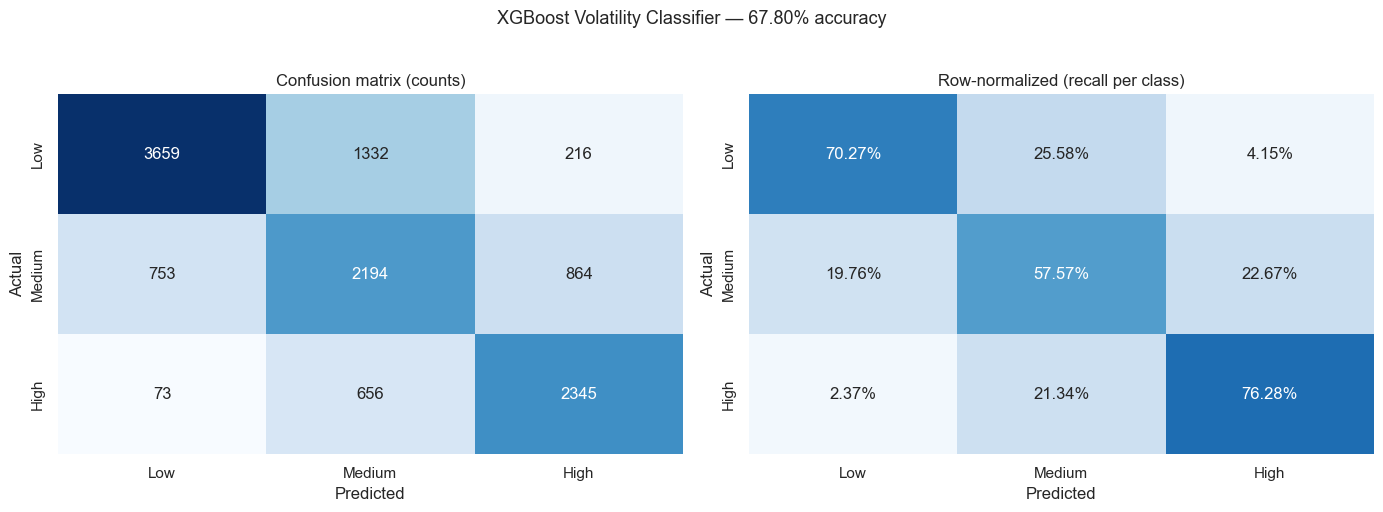

In [13]:
cm = confusion_matrix(preds["actual_regime"], preds["predicted_regime"])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ["Low", "Medium", "High"]

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=labels, yticklabels=labels, cbar=False)
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion matrix (counts)")

sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues", ax=axes[1],
            xticklabels=labels, yticklabels=labels, cbar=False, vmin=0, vmax=1)
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].set_title("Row-normalized (recall per class)")

plt.suptitle(f"XGBoost Volatility Classifier — {overall_acc*100:.2f}% accuracy",
             y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 4. Feature importance

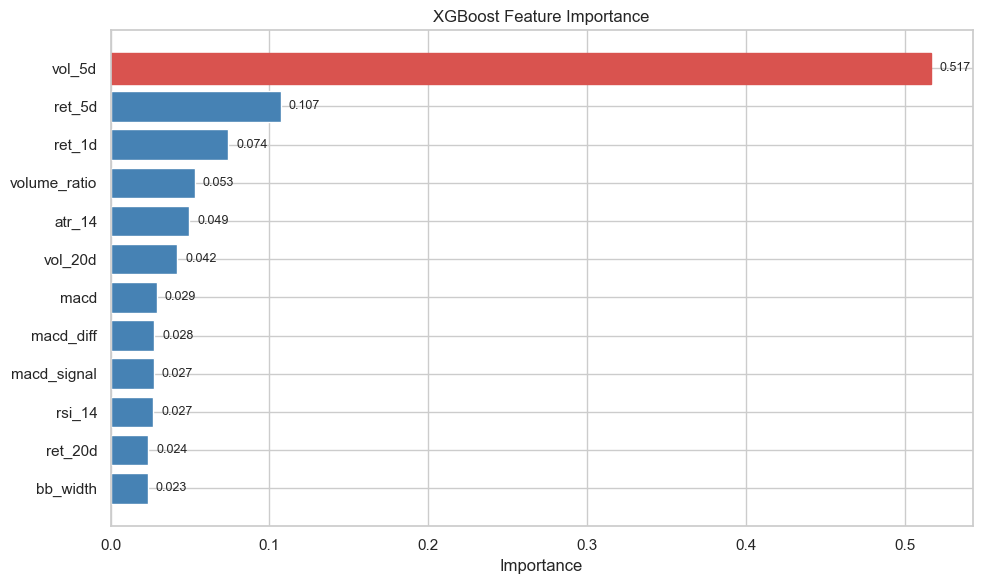

In [14]:
FEATURE_COLS = [
    "ret_1d", "ret_5d", "ret_20d",
    "vol_5d", "vol_20d", "bb_width", "atr_14",
    "rsi_14", "macd", "macd_signal", "macd_diff",
    "volume_ratio",
]

importances = model.feature_importances_
ranked = sorted(zip(FEATURE_COLS, importances), key=lambda x: x[1], reverse=True)
feats, imps = zip(*ranked)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(feats[::-1], imps[::-1], color="steelblue")
bars[-1].set_color("#d9534f")
ax.set_xlabel("Importance")
ax.set_title("XGBoost Feature Importance")
for bar, val in zip(bars, imps[::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

**Observations:**

- `vol_5d` dominates at 52% of total importance — the model independently discovered
  **volatility clustering**: recent realized vol is overwhelmingly the best predictor of
  near-future realized vol. This matches decades of quantitative finance literature.
- Recent-return magnitudes (`ret_5d`, `ret_1d`) come next — magnitude matters more than
  direction for vol prediction.
- Momentum oscillators (RSI, MACD) sit at the bottom. These are *directional* signals;
  less useful for predicting vol magnitude.
- The flat tail (most features in 0.02-0.05 range) confirms the model isn't over-relying
  on any single non-vol feature.

## 5. Probability calibration — confidence vs accuracy

A well-calibrated classifier has predictions whose probabilities reflect real accuracy.
Key question: when our model says "70% confident," is it actually right 70% of the time?

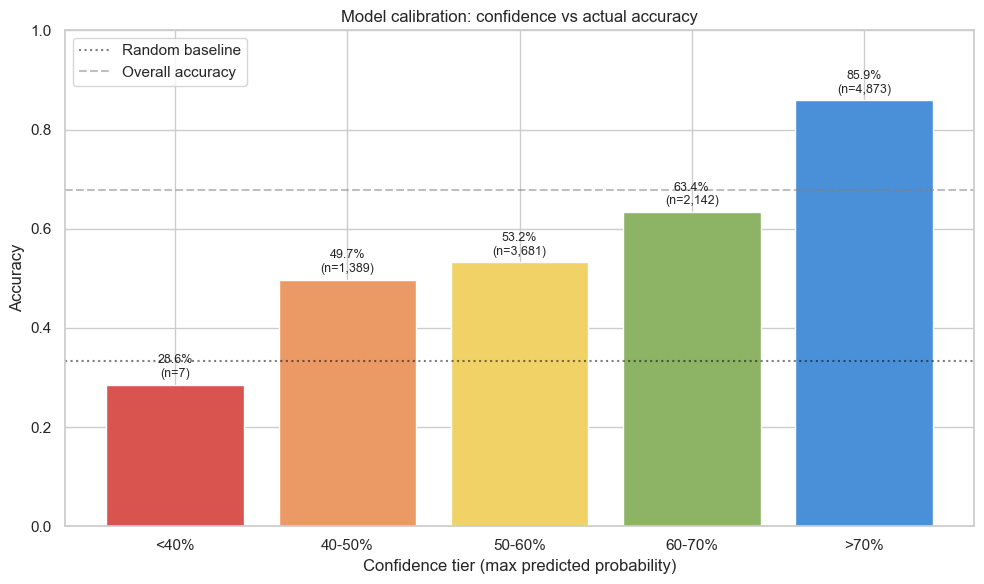


Calibration summary:
conf_bucket  mean_accuracy    n
       <40%       0.285714    7
     40-50%       0.497480 1389
     50-60%       0.532192 3681
     60-70%       0.633987 2142
       >70%       0.859430 4873


In [15]:
preds["conf_bucket"] = pd.cut(
    preds["confidence"],
    bins=[0, 0.4, 0.5, 0.6, 0.7, 1.0],
    labels=["<40%", "40-50%", "50-60%", "60-70%", ">70%"],
)
calibration = preds.groupby("conf_bucket", observed=True).agg(
    mean_accuracy=("correct", "mean"),
    n=("correct", "count"),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    calibration["conf_bucket"].astype(str),
    calibration["mean_accuracy"],
    color=["#d9534f", "#eb9a66", "#f0d267", "#8db365", "#4a90d9"],
)
for bar, acc, n in zip(bars, calibration["mean_accuracy"], calibration["n"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f"{acc*100:.1f}%\n(n={int(n):,})", ha="center", fontsize=9)
ax.axhline(y=0.333, linestyle=":", color="black", alpha=0.5, label="Random baseline")
ax.axhline(y=overall_acc, linestyle="--", color="gray", alpha=0.5, label="Overall accuracy")
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_xlabel("Confidence tier (max predicted probability)")
ax.set_title("Model calibration: confidence vs actual accuracy")
ax.legend()
plt.tight_layout()
plt.show()

print("\nCalibration summary:")
print(calibration.to_string(index=False))

**Why this matters more than the headline number.**

The overall 67.8% accuracy understates the model's usefulness:

- **>70% confidence tier: 86% accuracy** over 4,874 predictions (40% of test set)
- Low-confidence predictions (<50%) are near-random, as they should be

This means the model self-reports its reliability accurately. In dashboard use, a
confidence threshold can be applied — users get high-quality predictions when
the model is confident, and honest uncertainty when it isn't. This calibration is
arguably a more valuable property than raw accuracy.

## 6. Accuracy over time — does the model stay stable?

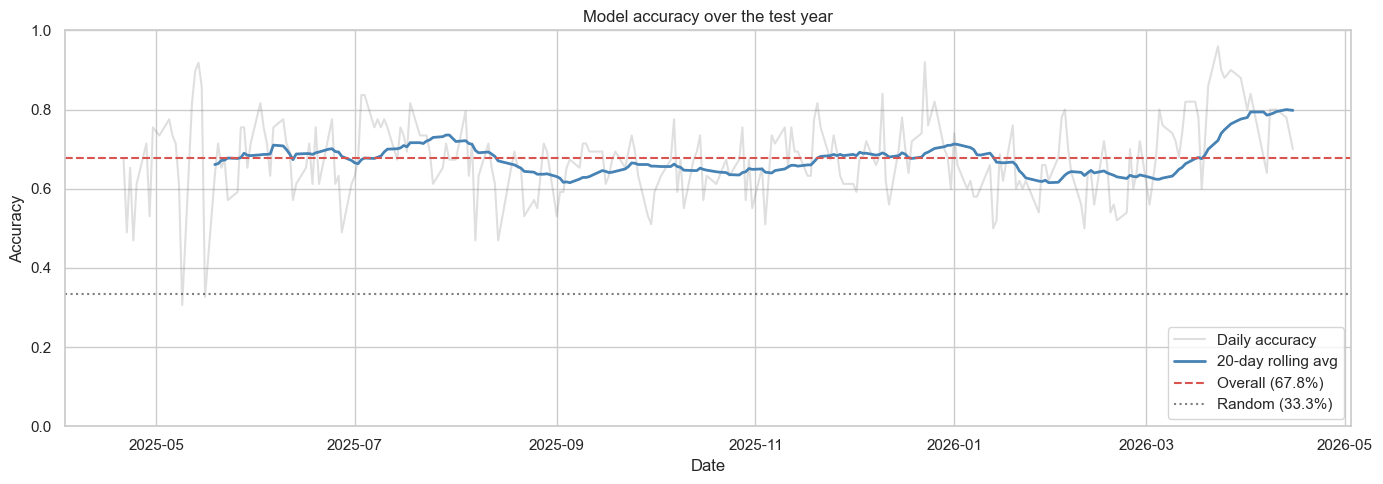

In [16]:
daily = preds.groupby("date").agg(
    accuracy=("correct", "mean"),
    n=("correct", "count"),
).reset_index()
daily["rolling_acc"] = daily["accuracy"].rolling(20).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily["date"], daily["accuracy"], alpha=0.25, color="gray", label="Daily accuracy")
ax.plot(daily["date"], daily["rolling_acc"], linewidth=2, color="steelblue",
        label="20-day rolling avg")
ax.axhline(y=overall_acc, linestyle="--", color="#d9534f",
           label=f"Overall ({overall_acc*100:.1f}%)")
ax.axhline(y=0.333, linestyle=":", color="black", alpha=0.5, label="Random (33.3%)")
ax.set_ylim(0, 1)
ax.set_title("Model accuracy over the test year")
ax.set_ylabel("Accuracy"); ax.set_xlabel("Date")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Interpretation:** Accuracy fluctuates around 68% but doesn't systematically degrade
over the test year — the rolling average stays in roughly the 55-80% band. No evidence
of model decay, which is often a concern for financial time-series models. In production,
monthly retraining would be a natural cadence.

## 7. Summary of findings

1. **Target definition matters more than model complexity.** Moving from next-day to
   next-5-day volatility — a single-line change — moved accuracy from 39% → 68%.
   This is arguably the most important ML lesson from the project.

2. **The model learned volatility clustering.** `vol_5d` alone carries 52% of feature
   importance. Academic literature on vol clustering was independently recovered by the
   classifier.

3. **The classifier is well-calibrated.** Predictions with >70% confidence are 86%
   accurate across 4,874 test examples — a practical, dashboard-useful result.

4. **Hyperparameter search yielded marginal returns.** Across 7 configurations
   (depths 3-7, learning rates 0.02-0.1, various regularization strengths), all
   converged within 0.5pp of the default. The model is bounded by signal, not
   by hyperparameters.

5. **Known limitations:**
   - Per-ticker tertile boundaries were computed using the full dataset (minor leakage
     of test-period information into target definition). A production system would
     use training-only tertiles.
   - "Medium" class has the lowest recall (58%) — structurally the hardest to predict
     since it sits between cleaner tails.
   - 1-year test window covers a specific market regime (2025-2026); robustness across
     regime changes is untested.